## PART B – Practical Implementation

# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

from statsmodels.stats.weightstats import ztest

## Load Dataset

In [4]:
df = pd.read_csv("health_dataset_200.csv")

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
  record_id age_group  age  weight  gender region smoking_status  \
0  b5029371     46-60   56      71    Male  North  Former Smoker   
1  0793b358       60+   69      53  Female   West         Smoker   
2  7798beee     46-60   46     106  Female  North  Former Smoker   
3  3dce3b2a     26-35   32      81  Female   East         Smoker   
4  34f3b6e1     46-60   60      95  Female   West     Non-Smoker   

  exercise_frequency    bmi  blood_pressure  diabetes  hypertension  \
0             Rarely  28.61           94.70      True          True   
1              Daily  27.18          118.37     False          True   
2              Daily  25.46          124.82     False         False   
3             Rarely  27.82          140.41     False          True   
4             Weekly  24.04           97.46     False          True   

   cholesterol_level  glucose_level  visit_date  
0             271.28         108.39  2024-08-16  
1             151.35         173.14 

---
# TASK 1: HYPOTHESIS FORMULATION
---

In [5]:
print("\nHypothesis 1")
print("H0: Smoking has no effect on Diabetes")
print("H1: Smoking affects Diabetes")

print("\nHypothesis 2")
print("H0: Age and BMI are not related")
print("H1: Age and BMI are related")



Hypothesis 1
H0: Smoking has no effect on Diabetes
H1: Smoking affects Diabetes

Hypothesis 2
H0: Age and BMI are not related
H1: Age and BMI are related


---
# TASK 2: CONFIDENCE INTERVAL
---


In [6]:
mean_weight = df['weight'].mean()
std_weight = df['weight'].std()
n = len(df)

confidence_interval = norm.interval(
    confidence=0.95,
    loc=mean_weight,
    scale=std_weight / np.sqrt(n)
)

print("\n95% Confidence Interval:")
print(confidence_interval)


95% Confidence Interval:
(np.float64(74.82572436969106), np.float64(80.12427563030893))


---
# TASK 3: CRITICAL VALUE & P-VALUE
---

In [7]:
critical_value = 1.96

print("\nCritical Value (95% Confidence):")
print(critical_value)



Critical Value (95% Confidence):
1.96



---
# TASK 4: ONE SAMPLE Z-TEST
---

In [8]:
z_stat, p_value = ztest(
    df['weight'],
    value=70
)

print("\nZ-Test Result")
print("Z Statistic =", z_stat)
print("P Value =", p_value)

if p_value < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to Reject H0")
    


Z-Test Result
Z Statistic = 5.530089288115501
P Value = 3.2006783247984675e-08
Decision: Reject H0


---
# TASK 5: CHI-SQUARE TEST
---

In [9]:
contingency_table = pd.crosstab(
    df['smoking_status'],
    df['diabetes']
)

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print("\nChi-Square Test")
print("Chi-Square Statistic =", chi2)
print("P Value =", p)

if p < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to Reject H0")



Chi-Square Test
Chi-Square Statistic = 0.308642400703105
P Value = 0.856996709154432
Decision: Fail to Reject H0


---
# TASK 6: ANOVA TEST
---

In [10]:
group1 = df[df['age_group'] == '18-25']['bmi']
group2 = df[df['age_group'] == '26-35']['bmi']
group3 = df[df['age_group'] == '36-45']['bmi']
group4 = df[df['age_group'] == '46-60']['bmi']

f_stat, p_anova = f_oneway(
    group1,
    group2,
    group3,
    group4
)

print("\nANOVA Test")
print("F Statistic =", f_stat)
print("P Value =", p_anova)

if p_anova < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to Reject H0")



ANOVA Test
F Statistic = 1.907583202129023
P Value = 0.13043007395325373
Decision: Fail to Reject H0


---
# TASK 7: COVARIANCE
---

In [11]:
covariance = df['age'].cov(df['bmi'])

print("\nCovariance")
print(covariance)


Covariance
-9.255543969849246


---
# TASK 8: CORRELATION
---

In [12]:
correlation = df['age'].corr(df['bmi'])

print("\nCorrelation")
print(correlation)



Correlation
-0.13627365084891752


---
# VISUALIZATION 1
---

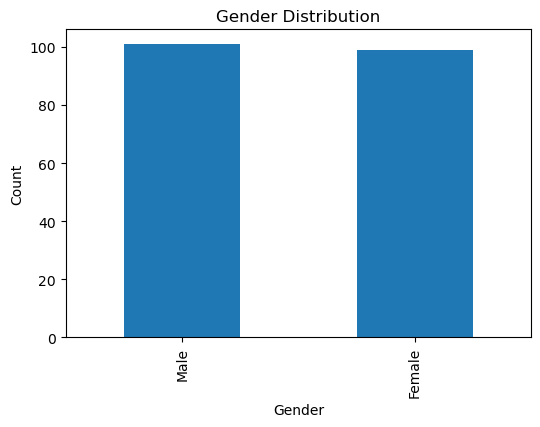

In [13]:
plt.figure(figsize=(6,4))
df['gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

---
# VISUALIZATION 2
---

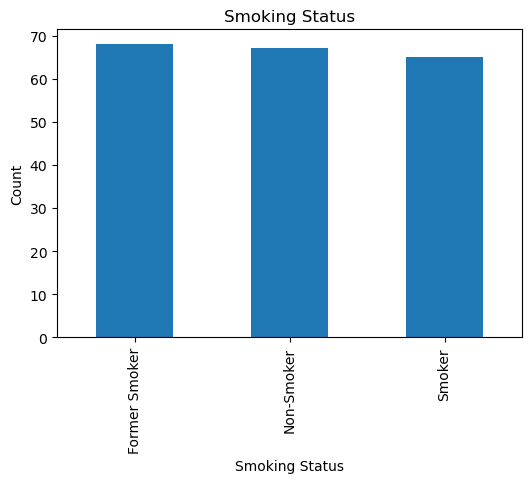

In [14]:
plt.figure(figsize=(6,4))
df['smoking_status'].value_counts().plot(kind='bar')
plt.title("Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.show()

----
# VISUALIZATION 3
----

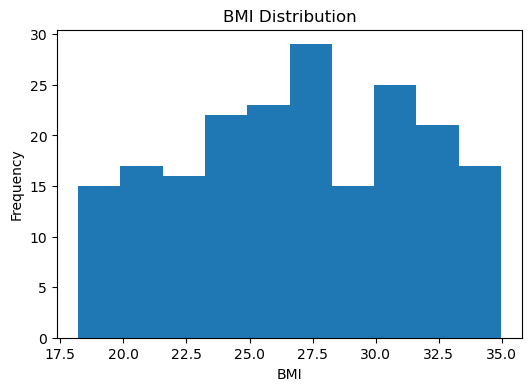

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df['bmi'], bins=10)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Frequency")
plt.show()


---
# VISUALIZATION 4
---

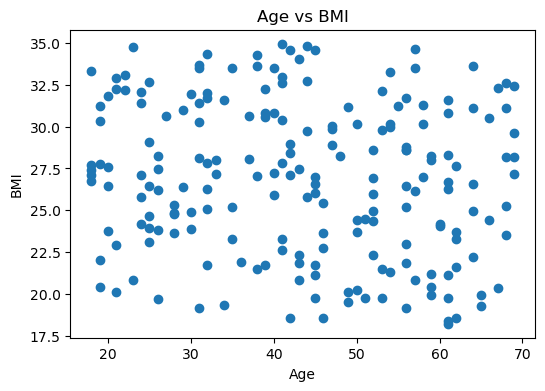

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df['age'], df['bmi'])
plt.title("Age vs BMI")
plt.xlabel("Age")
plt.ylabel("BMI")
plt.show()


# ==========================================
# FINAL CONCLUSION
# ==========================================


In [17]:
print("\nPROJECT COMPLETED SUCCESSFULLY")
print("All statistical tests performed.")


PROJECT COMPLETED SUCCESSFULLY
All statistical tests performed.
